In [1]:
# Import Packages
import pandas as pd
import copy as c
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df_dataset = pd.read_csv("./data/job_market_dataset.csv")
c_df = c.deepcopy(df_dataset)
c_df

,country,city,occupation,field,years_of_experience,salary,employment_type,education_level,gender,company_size,year,month
0,Switzerland,Zurich,Operations Manager,Operations,16,359609.0,work_from_home,Master,Male,Large,2023,8
1,India,Bangalore,HR Analyst,Human Resources,12,79059.0,part_time,PhD,Male,Large,2023,5
2,Sweden,Stockholm,Software Engineer,Technology,10,258077.0,freelance,Master,Male,Enterprise,2023,9
3,South Korea,Seoul,Operations Manager,Operations,7,252282.0,part_time,Master,Female,Large,2024,12
4,United States,New York,Cloud Engineer,Technology,4,330618.0,part_time,Master,Male,Enterprise,2022,1
...,...,...,...,...,...,...,...,...,...,...,...,...
499995,South Korea,Seoul,Software Engineer,Technology,1,161602.0,full_time,Bachelor,Other,Enterprise,2025,12
499996,Germany,Berlin,Business Analyst,Business,3,245796.0,freelance,PhD,Male,Enterprise,2022,10
499997,Australia,Sydney,Operations Manager,Operations,13,244323.0,work_from_home,Bachelor,Other,Large,2025,11
499998,Australia,Sydney,AI Engineer,Technology,9,297982.0,full_time,Master,Other,Large,2022,11


#### Average Salary For Each Departement

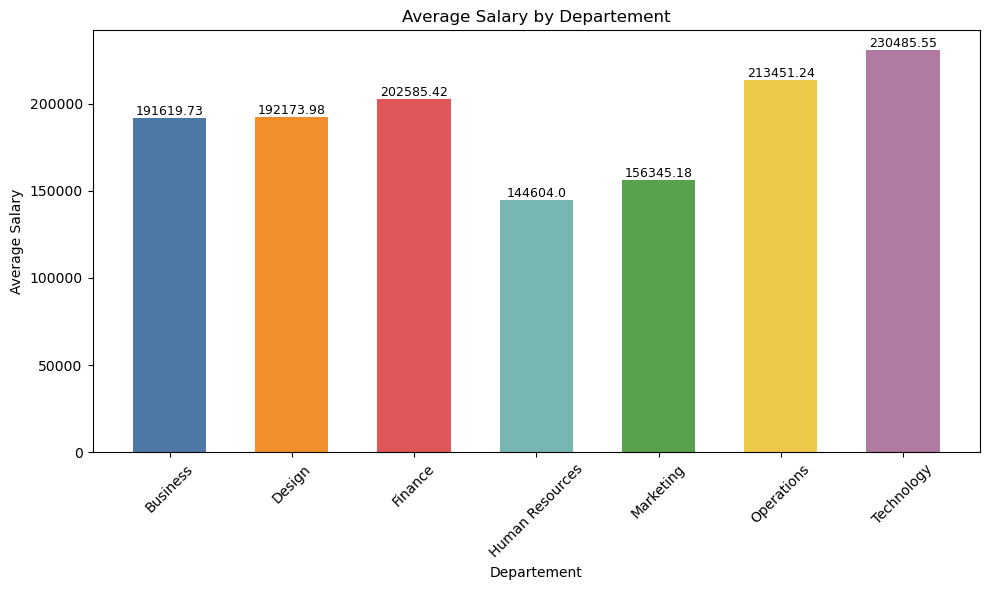

In [3]:
# Prepare data by DataFrame that Has Filed With Salary
df_salary_field = pd.concat([c_df["field"], c_df["salary"]], axis=1)
df_group = df_salary_field.groupby("field")["salary"].mean().round(2)

salary_list = df_group.values
departement_list = df_group.index

# Define Colors
bar_colors = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F", "#EDC948", "#B07AA1"]

# Plot bars
plt.figure(figsize=(10,6))
bars = plt.bar(departement_list, salary_list, color=bar_colors, width=0.6)

# Define Labels and title
plt.xlabel("Departement")
plt.ylabel("Average Salary")
plt.title("Average Salary by Departement")
plt.xticks(rotation=45)

# Show salary as number on each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, f"{yval}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

#### Top Hiring Countries

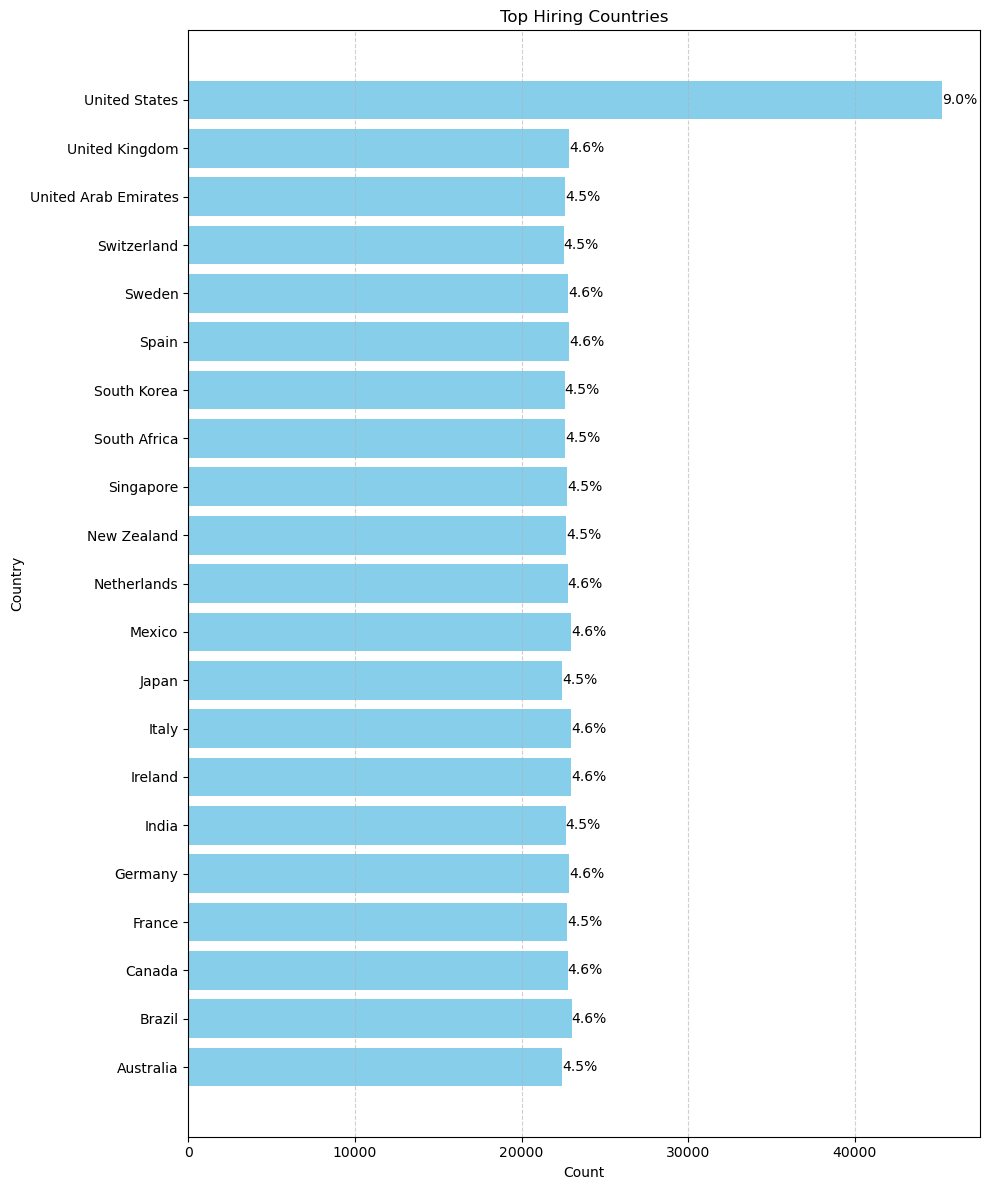

In [4]:
# Get Number Of Employees for Each Country
df_country = pd.DataFrame(c_df["country"])
df_group_by_country = df_country.groupby(by=["country"]).size().reset_index(name="count")

# Plot Bars
size_dataset = c_df["country"].count()

country_list = df_group_by_country["country"].to_list()
count_list = df_group_by_country["count"].to_list()

plt.figure(figsize=(10,12))
plt.barh(country_list, count_list, color="skyblue")
for i, v in enumerate(count_list):
    percent = (v * 100) / size_dataset
    plt.text(v + 0.2, i, f"{percent:.1f}%", va='center')  # shows 1 decimal
plt.xlabel("Count")
plt.ylabel("Country")
plt.title("Top Hiring Countries")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()

#### Experience vs Salary

,country,city,occupation,field,years_of_experience,salary,employment_type,education_level,gender,company_size,year,month
0,Switzerland,Zurich,Operations Manager,Operations,16,359609.0,work_from_home,Master,Male,Large,2023,8
1,India,Bangalore,HR Analyst,Human Resources,12,79059.0,part_time,PhD,Male,Large,2023,5
2,Sweden,Stockholm,Software Engineer,Technology,10,258077.0,freelance,Master,Male,Enterprise,2023,9
3,South Korea,Seoul,Operations Manager,Operations,7,252282.0,part_time,Master,Female,Large,2024,12
4,United States,New York,Cloud Engineer,Technology,4,330618.0,part_time,Master,Male,Enterprise,2022,1


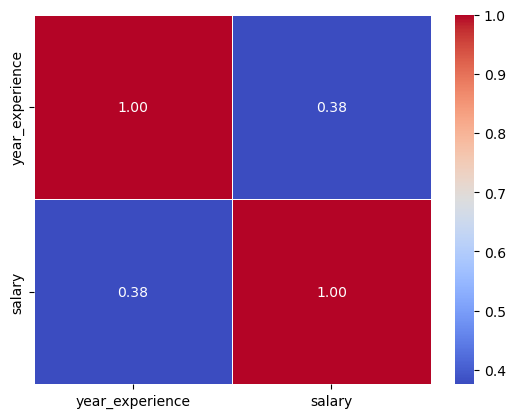

In [5]:
# Correlation
# Make DataFrame For Years of Expeience and Salary
df_year_experience = pd.DataFrame(c_df["years_of_experience"])
df_salary = pd.DataFrame(c_df["salary"])

df_year_experience_salary = pd.concat([df_year_experience, df_salary], ignore_index=True, axis=1)
df_year_experience_salary.rename(columns={0: "year_experience", 1: "salary"}, inplace=True)
df_year_experience_salary

# Get Correlation Between Salary and Experience
correlation = df_year_experience_salary.corr(method="pearson")


sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

c_df.head()

How does experience impact salary?
As we can see, the relationship between years of experience and salary is weak. \
This is normal because there are other contributing factors, such as the country of employment, \
work arrangement (on-site, remote, or part-time), and the size of the company. (in Our Case Data Is Not Real)

#### Female/Male for Each Deperatement

Text(0.5, 1.0, 'Distribution of <Female> Gender Across Departments')

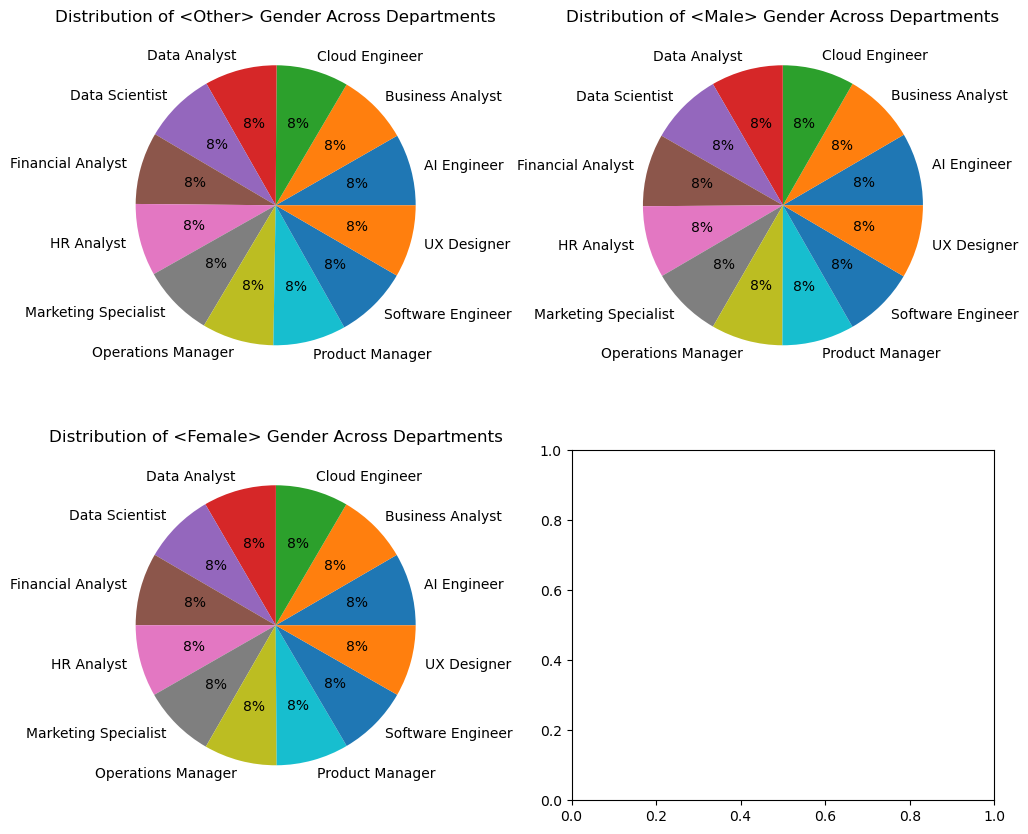

In [6]:
# Get DataSet For Make
df_male = c_df.where(c_df["gender"] == "Male").dropna()
df_male
# Get DataSet For Female
df_female = c_df.where(c_df["gender"] == "Female").dropna()
df_female
# Get DataSet For Others
df_other = c_df.where(c_df["gender"] == "Other").dropna()
df_other

# Get For Each Departement Percentage of Gender --> Male
gr_df_male = pd.DataFrame(df_male.groupby(by="occupation")["gender"].count()).reset_index()

# Get For Each Departement Percentage of Gender --> Female
gr_df_female = pd.DataFrame(df_female.groupby(by="occupation")["gender"].count()).reset_index()

# Get For Each Departement Percentage of Gender --> Other
gr_df_other = pd.DataFrame(df_other.groupby(by="occupation")["gender"].count()).reset_index()

# Display for Each Gender Existance Percentage for Each Departement
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0, 0].pie(gr_df_other["gender"], labels=gr_df_other["occupation"], autopct="%1.0f%%")
ax[0, 0].set_title("Distribution of <Other> Gender Across Departments")

ax[0, 1].pie(gr_df_male["gender"], labels=gr_df_male["occupation"], autopct="%1.0f%%")
ax[0, 1].set_title("Distribution of <Male> Gender Across Departments")

ax[1, 0].pie(gr_df_female["gender"], labels=gr_df_female["occupation"], autopct="%1.0f%%")
ax[1, 0].set_title("Distribution of <Female> Gender Across Departments")

#### How do salaries vary across locations and employment types?

<AxesSubplot: xlabel='city'>

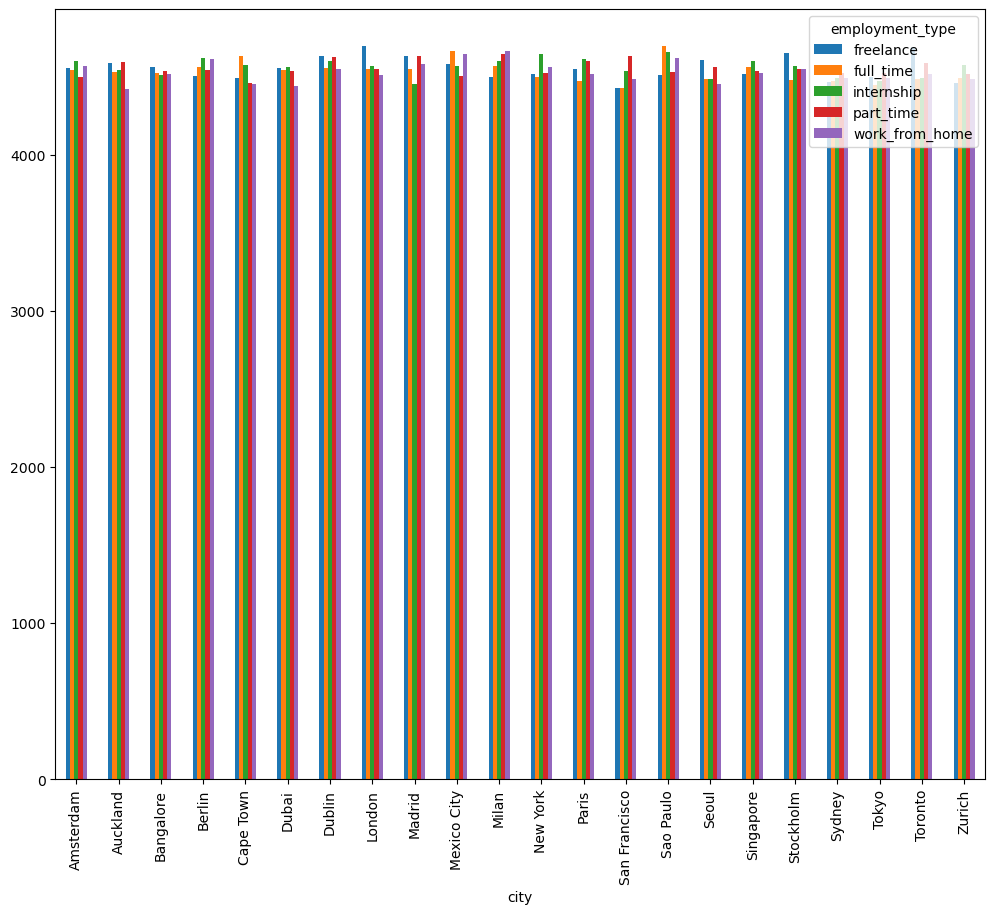

In [7]:
c_df["employment_type"]
c_df["salary"]
c_df["city"]

df_emp_sal_loc = pd.concat([c_df["employment_type"], c_df["salary"], c_df["city"]], axis=1)


# Get Salary For Each Location by Catagorie of Employment type
df_emp_sal_loc
gr_location_by_emplo_type = pd.DataFrame(df_emp_sal_loc.groupby(by=["city", "employment_type"])["salary"].count()).reset_index()
gr_location_by_emplo_type

# Draw Plot --> Pivot Table
pivot_df = gr_location_by_emplo_type.pivot(index="city", columns="employment_type", values="salary")
pivot_df.plot(kind="bar", figsize=(12, 10))

#### Descriptive statistics (mean, median, mode, std)

In [ ]:
# Descriptive statistics (mean, median, mode, std)
c_df.describe()

,years_of_experience,salary,year,month
count,500000.000000,500000.000000,500000.000000,500000.000000
mean,11.865168,207019.212078,2023.498806,6.504852
std,7.178829,85867.307373,1.117754,3.450244
min,0.000000,12000.000000,2022.000000,1.000000
25%,6.000000,142803.000000,2022.000000,4.000000
50%,12.000000,200236.500000,2023.000000,7.000000
75%,18.000000,267831.250000,2024.000000,10.000000
max,25.000000,370000.000000,2025.000000,12.000000


#### Statistic Description For Salary

In [9]:
import statistics as sc

# Statistic Descriptive For Salary
'''
    - Measures of Central Tendency:
        Mean: 207019.2 --> average salary
        Mode: 370000.0 --> salary that appears most often
        Median: 200236.5 --> middle salary value

    - Measures of Variability:
        Range: min = 12000.0, max = 370000.0
        Variance: 7,373,194,475.46 --> high variance, data is spread out
        Most salaries are roughly between:
            Mean - SD  --> 207,019 - 85,867 ≈ 121,152
            Mean + SD  --> 207,019 + 85,867 ≈ 292,886
'''

c_df
c_df["salary"]
sc.mean(c_df["salary"])
sc.mode(c_df["salary"])

salaries = sorted(c_df["salary"].to_list())
sc.median(salaries)

c_df["salary"].describe()
sc.variance(c_df["salary"])
sc.stdev(c_df["salary"])

85867.30737286207